# Task 11 – Knowledge Graph Extension

## 11.1 Purpose and Task-Specific Library

This task extends the citation network with paper and subject entities. NetworkX is imported here because it is used to build and visualize the small knowledge graph.

In [1]:
!pip install -q torch-geometric ogb streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 69.2 MB/s eta 0:00:00


In [2]:
import os
# Compatibility fix for trusted PyG objects downloaded by the official OGB package on PyTorch 2.6+.
os.environ['TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD'] = '1'

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
PROJECT_ROOT = Path('/content/drive/MyDrive/OGBN_Arxiv_Project')
RESULTS_ROOT = PROJECT_ROOT / 'results'
MODELS_DIR = PROJECT_ROOT / 'models'
SRC_DIR = PROJECT_ROOT / 'src'
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'

for folder in [PROJECT_ROOT, RESULTS_ROOT, MODELS_DIR, SRC_DIR, ARTIFACTS_DIR,
               PROJECT_ROOT / 'notebooks', PROJECT_ROOT / 'visualizations',
               PROJECT_ROOT / 'dashboard', PROJECT_ROOT / 'report',
               PROJECT_ROOT / 'presentation', PROJECT_ROOT / 'video']:
    folder.mkdir(parents=True, exist_ok=True)
print('Project root:', PROJECT_ROOT)

Mounted at /content/drive
Project root: /content/drive/MyDrive/OGBN_Arxiv_Project


In [6]:
import json, random, time, warnings, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch:', torch.__version__)
print('Device:', DEVICE)
if torch.cuda.is_available(): print('GPU:', torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cpu
Device: cpu


In [7]:
from ogb.nodeproppred import PygNodePropPredDataset
from torch_geometric.utils import to_undirected
from torch_geometric.data.storage import GlobalStorage
from torch_geometric.data.data import DataEdgeAttr
from torch_geometric.data.data import DataTensorAttr # Import DataTensorAttr
import torch

torch.serialization.add_safe_globals([GlobalStorage, DataEdgeAttr, DataTensorAttr]) # Add DataTensorAttr to safe globals

dataset = PygNodePropPredDataset(name='ogbn-arxiv', root=str(PROJECT_ROOT / 'data'))
data = dataset[0]
x_original = data.x.float()
y = data.y.view(-1).long()
edge_index_directed = data.edge_index.long()
N, E, F_DIM, NUM_CLASSES = data.num_nodes, data.num_edges, data.num_features, dataset.num_classes
print(data)

Data(num_nodes=169343, edge_index=[2, 1166243], x=[169343, 128], node_year=[169343, 1], y=[169343, 1])


In [8]:
import networkx as nx
from torch_geometric.data import HeteroData

# Knowledge graph design


The citation graph is extended with two entity types: paper and subject. Citation edges remain paper-to-paper relations. A belongs_to relation connects training papers only to subject nodes. Validation and test labels are deliberately excluded so target labels cannot leak into model inputs.

In [13]:
OUTPUT = ARTIFACTS_DIR

split = dataset.get_idx_split()
train_idx = split['train'].view(-1)

knowledge_graph = HeteroData()
knowledge_graph['paper'].x = x_original
knowledge_graph['subject'].x = torch.eye(NUM_CLASSES)
knowledge_graph['paper', 'cites', 'paper'].edge_index = edge_index_directed
knowledge_graph['paper', 'belongs_to', 'subject'].edge_index = torch.stack([train_idx, y[train_idx]])
knowledge_graph['subject', 'has_paper', 'paper'].edge_index = torch.stack([y[train_idx], train_idx])

print(knowledge_graph)
torch.save(knowledge_graph, OUTPUT / 'ogbn_arxiv_knowledge_graph.pt')

relation_summary = pd.DataFrame({
    'relation': ['paper-cites-paper', 'training-paper-belongs-to-subject', 'subject-has-training-paper'],
    'edges': [E, len(train_idx), len(train_idx)]
})
display(relation_summary)
relation_summary.to_csv(OUTPUT / 'knowledge_graph_relations.csv', index=False)

HeteroData(
  paper={ x=[169343, 128] },
  subject={ x=[40, 40] },
  (paper, cites, paper)={ edge_index=[2, 1166243] },
  (paper, belongs_to, subject)={ edge_index=[2, 90941] },
  (subject, has_paper, paper)={ edge_index=[2, 90941] }
)


,relation,edges
0,paper-cites-paper,1166243
1,training-paper-belongs-to-subject,90941
2,subject-has-training-paper,90941


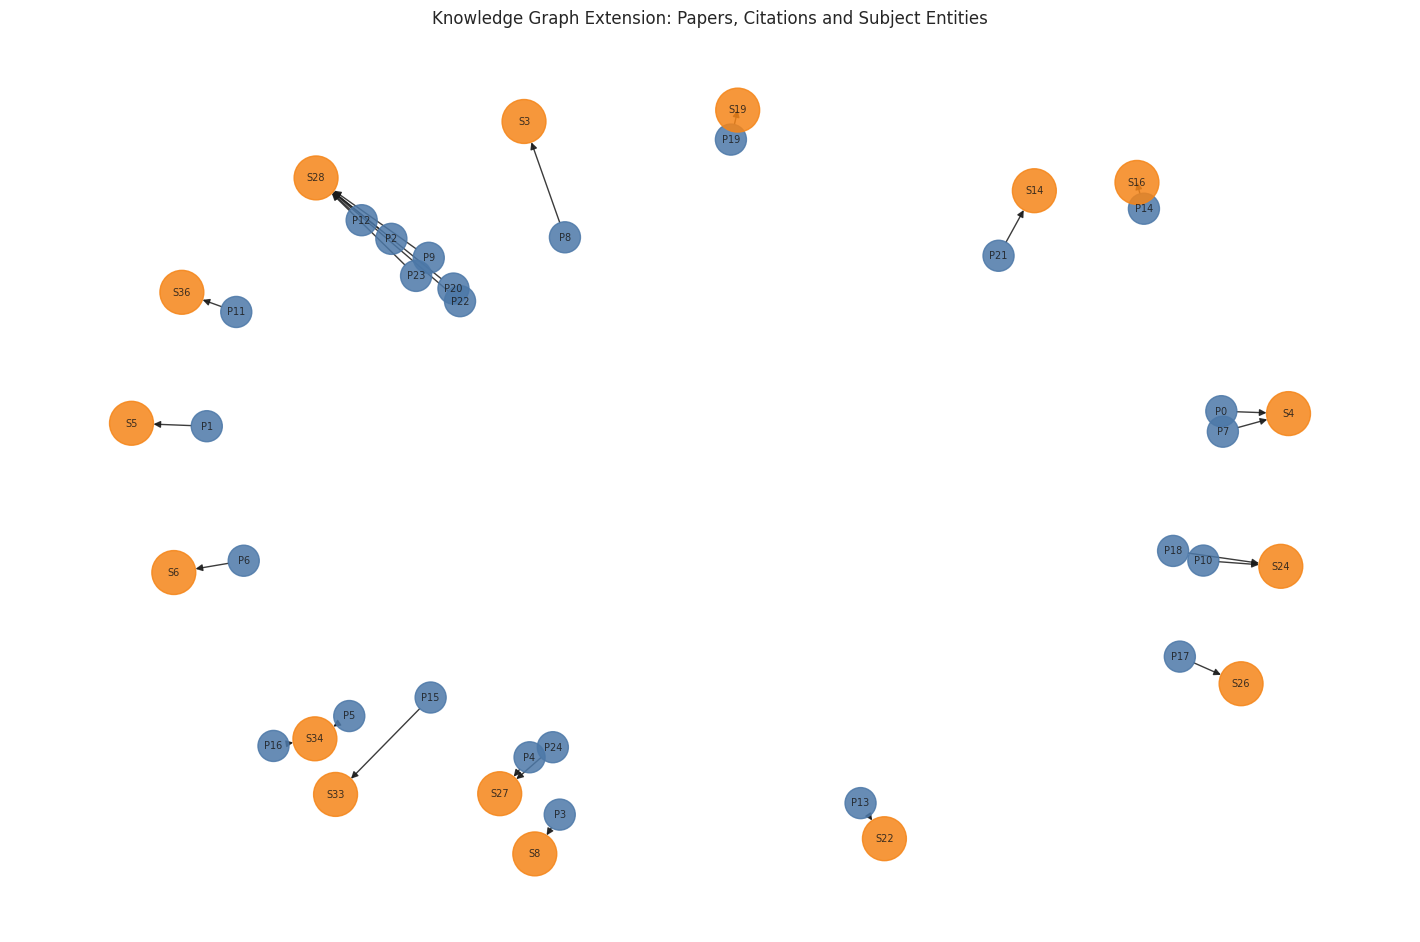

In [15]:
OUTPUT = ARTIFACTS_DIR

# Visualize a small leakage-safe training-paper/subject knowledge graph
sample_papers = train_idx[:25]
KG = nx.DiGraph()
for paper in sample_papers.tolist():
    KG.add_node(f'P{paper}', kind='paper')
    subject = int(y[paper])
    KG.add_node(f'S{subject}', kind='subject')
    KG.add_edge(f'P{paper}', f'S{subject}', relation='belongs_to')

mask = torch.isin(edge_index_directed[0], sample_papers) & torch.isin(edge_index_directed[1], sample_papers)
for source_id, target_id in edge_index_directed[:, mask].t().tolist():
    KG.add_edge(f'P{source_id}', f'P{target_id}', relation='cites')

colors = ['#4C78A8' if KG.nodes[n]['kind']=='paper' else '#F58518' for n in KG.nodes]
sizes = [500 if KG.nodes[n]['kind']=='paper' else 1000 for n in KG.nodes]
plt.figure(figsize=(14,9)); pos = nx.spring_layout(KG, seed=SEED)
nx.draw(KG, pos, node_color=colors, node_size=sizes, with_labels=True,
        font_size=7, arrows=True, alpha=.85)
plt.title('Knowledge Graph Extension: Papers, Citations and Subject Entities')
plt.tight_layout(); plt.savefig(OUTPUT / 'knowledge_graph_sample.png', dpi=250); plt.show()

## 11.2 Interpretation

The triple table follows the subject–relationship–object format. Paper nodes can cite other papers and belong to subject nodes. The extension adds semantic meaning and could later include authors, publication years, or institutions.